`Tune the learning rate and number of epochs, and note how accuracy changes.
`
Learning rate and number of epochs are hyperparameters that can significantly affect the performance of a neural network. To tune these parameters, you can experiment with different values and observe how the accuracy changes.
1. **Learning Rate:**
 The learning rate determines how much to change the model in response to the estimated error each time the model weights are updated. A smaller learning rate may lead to a more accurate model, but it will take longer to converge. A larger learning rate may converge faster but can overshoot the optimal solution.

2. **Number of Epochs:**
 The number of epochs is the number of times the learning algorithm will work through the entire training dataset. More epochs can lead to better learning, but too many epochs can cause overfitting, where the model performs well on the training data but poorly on unseen data.


In [1]:
import tensorflow as tf
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create a toy dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Function to create and train the model
def train_model(learning_rate, epochs):

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation="relu", input_shape=(2,)),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    # Set the learning rate
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Train the model
    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=32,
        verbose=0
    )

    # Evaluate on test data
    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    return accuracy


# Different learning rates
learning_rates = [0.001, 0.01, 0.1]

# Different numbers of epochs
epochs_list = [10, 50, 100]

# Test different combinations
for lr in learning_rates:
    for epochs in epochs_list:

        accuracy = train_model(lr, epochs)

        print(
            f"Learning Rate: {lr}, "
            f"Epochs: {epochs}, "
            f"Accuracy: {accuracy:.4f}"
        )

c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Learning Rate: 0.001, Epochs: 10, Accuracy: 0.8750
Learning Rate: 0.001, Epochs: 50, Accuracy: 0.9700
Learning Rate: 0.001, Epochs: 100, Accuracy: 0.9750
Learning Rate: 0.01, Epochs: 10, Accuracy: 0.9650
Learning Rate: 0.01, Epochs: 50, Accuracy: 0.9750
Learning Rate: 0.01, Epochs: 100, Accuracy: 0.9700
Learning Rate: 0.1, Epochs: 10, Accuracy: 0.9850
Learning Rate: 0.1, Epochs: 50, Accuracy: 0.9500
Learning Rate: 0.1, Epochs: 100, Accuracy: 0.9800


Learning Rate: 0.001, Epochs: 10, Accuracy: 0.8450
Learning Rate: 0.001, Epochs: 50, Accuracy: 0.9250
Learning Rate: 0.001, Epochs: 100, Accuracy: 0.9800
Learning Rate: 0.01, Epochs: 10, Accuracy: 0.9800
Learning Rate: 0.01, Epochs: 50, Accuracy: 0.9850
Learning Rate: 0.01, Epochs: 100, Accuracy: 0.9750
Learning Rate: 0.1, Epochs: 10, Accuracy: 0.9700
Learning Rate: 0.1, Epochs: 50, Accuracy: 0.9800
Learning Rate: 0.1, Epochs: 100, Accuracy: 0.9800


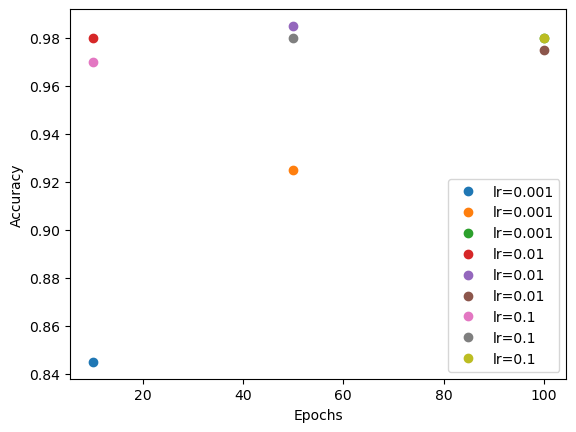

In [3]:
# ploting the accuracy changes with different learning rates and epochs

import matplotlib.pyplot as plt

# Different learning rates
learning_rates = [0.001, 0.01, 0.1]

# Different numbers of epochs
epochs_list = [10, 50, 100]

# Test different combinations  
for lr in learning_rates:
    for epochs in epochs_list:

        accuracy = train_model(lr, epochs)

        print(
            f"Learning Rate: {lr}, "
            f"Epochs: {epochs}, "
            f"Accuracy: {accuracy:.4f}"
        )

        plt.plot(epochs, accuracy, 'o', label=f"lr={lr}")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()